In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = 'data\\train_ro'
val_dir = 'data\\data1'
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(val_dir), data_transforms['val'])
}
dataloaders = {x: DataLoader(
    image_datasets[x],
    batch_size=32,  # 增加批次大小，充分利用 GPU
    shuffle=(x=='train'),
    num_workers=6,  # 根據您的 CPU 核心數調整
    pin_memory=True,  # 加速 CPU->GPU 數據傳輸
    prefetch_factor=2,  # 每個 worker 預加載的批次數
    persistent_workers=True  # 避免每個 epoch 後重啟 workers
) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

First, let's print the model architecture to understand its structure:

Run the above code to see the structure of the model. Look for the final layer that produces the class scores, typically named something like classifier, head, or fc.

In [3]:
# Step 4: Define the Model
# Load the ResNet-18 model (最輕量化的 ResNet 版本) and modify it for your number of classes.

import torchvision.models as models

# Load pretrained ResNet-18 model
model = models.resnet18(pretrained=False)

# Print the model architecture
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



從模型結構可以看出，ResNet-18 的最終分類層名為 fc (fully connected)。 

要為您的自訂分類任務修改此層，您應將 fc 層替換為具有適當輸出類別數量的新 Linear 層。

In [4]:

# Modify the final layer for custom classification
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))

In [5]:
# Move the model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [6]:
import torch.optim as optim
from torch.optim import lr_scheduler

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


In [7]:
import time
import copy
report_train_acc = []
report_val_acc = []
report_train_loss = []
report_val_loss = []
num_epochs = 50
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'train':
                report_train_acc.append(epoch_acc)
                report_train_loss.append(epoch_loss)
            else:
                report_val_acc.append(epoch_acc)
                report_val_loss.append(epoch_loss)
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Train the model
model = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs)

# Save the model
torch.save(model.state_dict(), 'unpre_res_45deg.pth')

Epoch 0/49
----------
train Loss: 9.2655 Acc: 0.0000
val Loss: 9.2275 Acc: 0.0001

Epoch 1/49
----------
train Loss: 9.2345 Acc: 0.0000
val Loss: 9.2234 Acc: 0.0001

Epoch 2/49
----------
train Loss: 9.1875 Acc: 0.0001
val Loss: 9.0931 Acc: 0.0002

Epoch 3/49
----------
train Loss: 8.7656 Acc: 0.0003
val Loss: 8.3345 Acc: 0.0016

Epoch 4/49
----------
train Loss: 7.6311 Acc: 0.0030
val Loss: 6.9931 Acc: 0.0083

Epoch 5/49
----------
train Loss: 5.8417 Acc: 0.0189
val Loss: 5.6137 Acc: 0.0229

Epoch 6/49
----------
train Loss: 4.7384 Acc: 0.0472
val Loss: 5.2337 Acc: 0.0304

Epoch 7/49
----------
train Loss: 4.0868 Acc: 0.0893
val Loss: 4.5508 Acc: 0.0550

Epoch 8/49
----------
train Loss: 3.6964 Acc: 0.1294
val Loss: 4.4088 Acc: 0.0662

Epoch 9/49
----------
train Loss: 3.4993 Acc: 0.1609
val Loss: 4.3720 Acc: 0.0649

Epoch 10/49
----------
train Loss: 3.4448 Acc: 0.1721
val Loss: 4.3619 Acc: 0.0665

Epoch 11/49
----------
train Loss: 3.4395 Acc: 0.1679
val Loss: 4.3401 Acc: 0.0685

Ep

# Testing

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
from tqdm import tqdm  # 添加進度條顯示
# 初始化模型架構
model = models.resnet18(pretrained=False)
# 修改分類器層以符合您的類別數量
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))

# 載入預訓練權重
model_path = "unpre_res_45deg.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 定義測試數據轉換 
test_transform = transforms.Compose([  
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomRotation([-360, 360]),  # 隨機旋轉範圍從 -360 度到 +360 
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    
])

# 載入測試數據集
test_dataset = datasets.ImageFolder('data\\data1', test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

# 使用動態類別數量
num_classes = len(test_dataset.classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
class_predictions = [0] * num_classes
total_correct = 0
total_samples = 0


# 計算開始時間
start_time = time.time()

# 使用進度條跟踪測試進度
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="測試進度"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 模型預測
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        
        # 統計整體正確數
        correct = (predictions == labels).sum().item()
        total_correct += correct
        total_samples += labels.size(0)
        
        # 統計每個類別的正確數和總數
        for i in range(len(labels)):
            label = labels[i].item()
            prediction = predictions[i].item()
            class_total[label] += 1
            if label == prediction:
                class_correct[label] += 1
            
            # 統計每個類別被預測的次數
            class_predictions[prediction] += 1

# 計算測試時間
test_time = time.time() - start_time

# 輸出總體準確率
overall_accuracy = 100 * total_correct / total_samples
print(f'總體準確率: {overall_accuracy:.2f}% ({total_correct}/{total_samples})')
print(f'測試完成，耗時: {test_time:.2f} 秒')

# 輸出每個類別的準確率
print("\n各類別準確率:")
for i in range(len(class_names)):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f'類別 {i}: {accuracy:.2f}% ({class_correct[i]}/{class_total[i]})')

# 輸出每個類別被預測到的次數
print("\n各類別被預測次數:")
for i in range(len(class_names)):
    print(f'類別 {i}: {class_predictions[i]}')

測試進度: 100%|██████████| 157/157 [00:28<00:00,  5.55it/s]

總體準確率: 8.52% (852/10000)
測試完成，耗時: 28.30 秒

各類別準確率:
類別 0: 100.00% (1/1)
類別 1: 0.00% (0/1)
類別 2: 0.00% (0/1)
類別 3: 0.00% (0/1)
類別 4: 0.00% (0/1)
類別 5: 0.00% (0/1)
類別 6: 0.00% (0/1)
類別 7: 0.00% (0/1)
類別 8: 0.00% (0/1)
類別 9: 0.00% (0/1)
類別 10: 0.00% (0/1)
類別 11: 100.00% (1/1)
類別 12: 100.00% (1/1)
類別 13: 0.00% (0/1)
類別 14: 0.00% (0/1)
類別 15: 0.00% (0/1)
類別 16: 0.00% (0/1)
類別 17: 100.00% (1/1)
類別 18: 0.00% (0/1)
類別 19: 0.00% (0/1)
類別 20: 0.00% (0/1)
類別 21: 0.00% (0/1)
類別 22: 0.00% (0/1)
類別 23: 100.00% (1/1)
類別 24: 0.00% (0/1)
類別 25: 0.00% (0/1)
類別 26: 0.00% (0/1)
類別 27: 0.00% (0/1)
類別 28: 0.00% (0/1)
類別 29: 0.00% (0/1)
類別 30: 0.00% (0/1)
類別 31: 0.00% (0/1)
類別 32: 0.00% (0/1)
類別 33: 100.00% (1/1)
類別 34: 100.00% (1/1)
類別 35: 0.00% (0/1)
類別 36: 0.00% (0/1)
類別 37: 0.00% (0/1)
類別 38: 0.00% (0/1)
類別 39: 0.00% (0/1)
類別 40: 0.00% (0/1)
類別 41: 0.00% (0/1)
類別 42: 0.00% (0/1)
類別 43: 0.00% (0/1)
類別 44: 0.00% (0/1)
類別 45: 100.00% (1/1)
類別 46: 0.00% (0/1)
類別 47: 0.00% (0/1)
類別 48: 0.00% (0/1)
類別 49: 0.00%

[2.500000e-05 3.750000e-05 5.000000e-05 2.500000e-04 2.975000e-03
 1.887500e-02 4.716250e-02 8.931250e-02 1.294375e-01 1.609125e-01
 1.721375e-01 1.679000e-01 1.616625e-01 1.646375e-01 1.936500e-01
 2.537875e-01 3.571875e-01 4.903375e-01 6.417250e-01 7.677875e-01
 8.545250e-01 9.101500e-01 9.466750e-01 9.656750e-01 9.797750e-01
 9.872875e-01 9.914750e-01 9.941750e-01 9.961000e-01 9.975875e-01
 9.981625e-01 9.979500e-01 9.972375e-01 9.957750e-01 9.938875e-01
 9.902250e-01 9.858875e-01 9.817750e-01 9.798375e-01 9.813250e-01
 9.820750e-01 9.866375e-01 9.904125e-01 9.935500e-01 9.964875e-01
 9.979250e-01 9.988375e-01 9.996875e-01 9.999375e-01 1.000000e+00]
[9.26554990e+00 9.23451917e+00 9.18754162e+00 8.76556496e+00
 7.63110491e+00 5.84168937e+00 4.73839041e+00 4.08684399e+00
 3.69635952e+00 3.49928416e+00 3.44477986e+00 3.43945523e+00
 3.38886457e+00 3.24008065e+00 2.95681242e+00 2.54447485e+00
 2.02932135e+00 1.52036937e+00 1.05087605e+00 6.89208264e-01
 4.40850232e-01 2.85886991e-01 1.7

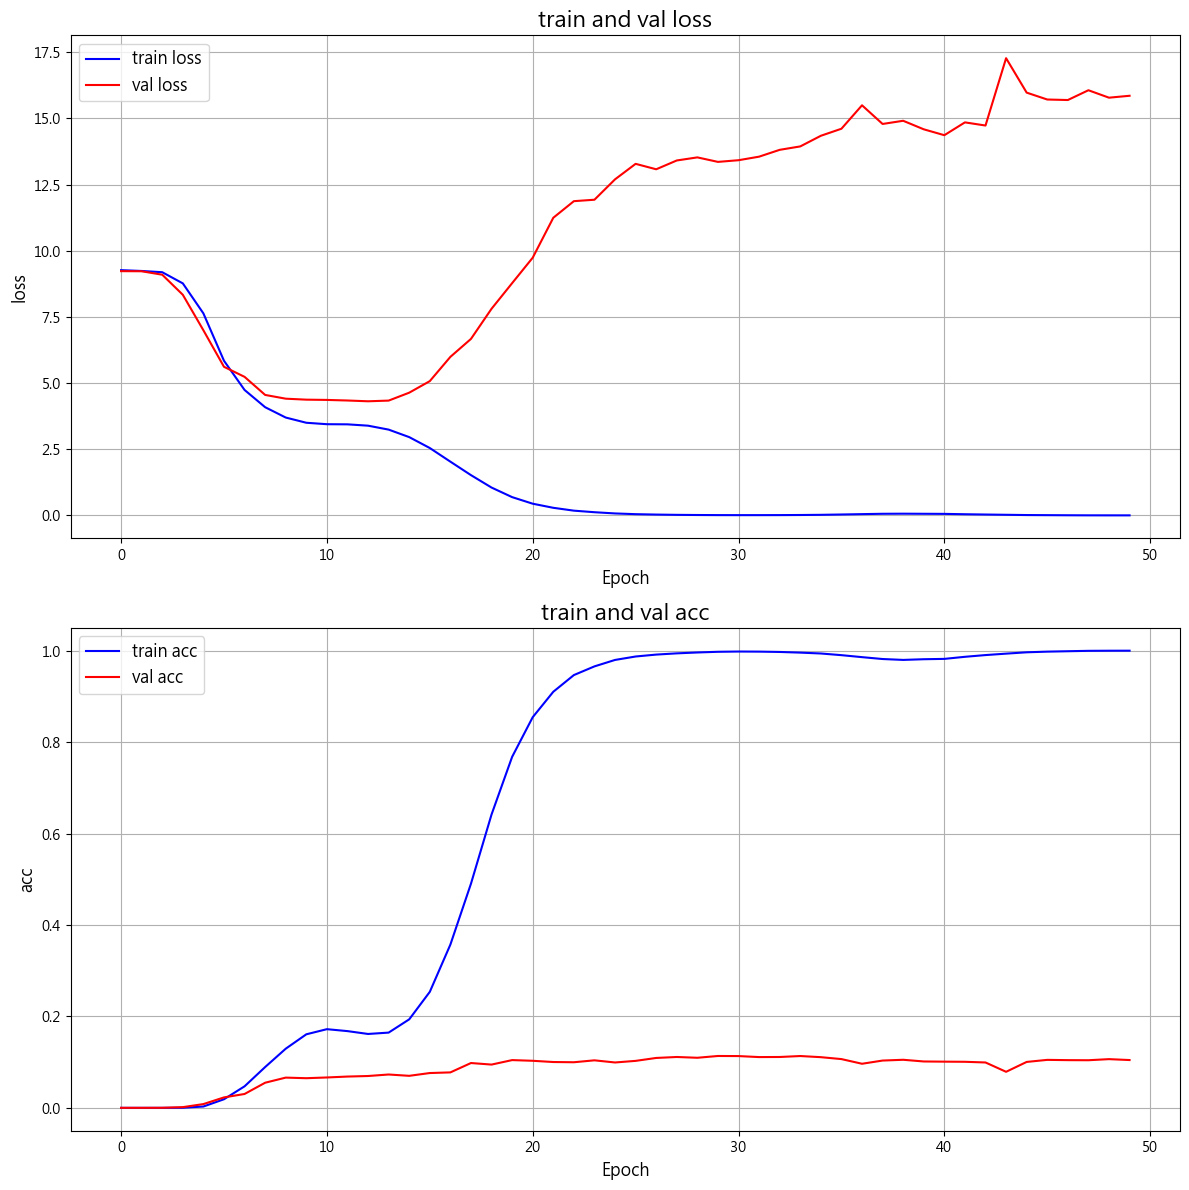

最終訓練損失: 0.0002, 最終訓練準確率: 1.0000
最終驗證損失: 15.8543, 最終驗證準確率: 0.1046


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

train_loss = report_train_loss

# 訓練準確率
train_acc = report_train_acc

val_acc = report_val_acc
# 驗證損失
val_loss = report_val_loss
# 從訓練記錄中提取數據
epochs = list(range(50))

train_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in train_acc])
train_loss = np.array([loss if isinstance(loss, float) else loss.cpu().item() for loss in train_loss])
val_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in val_acc])
val_loss = np.array([loss if isinstance(loss, float) else loss.cpu().item() for loss in val_loss])
print(train_acc)
print(train_loss)
print(val_acc)
print(val_loss)
# 設置中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 創建包含兩個子圖的圖表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 繪製損失曲線
ax1.plot(epochs, train_loss, 'b-', label='train loss')
ax1.plot(epochs, val_loss, 'r-', label='val loss')
ax1.set_title('train and val loss', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('loss', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# 繪製準確率曲線
ax2.plot(epochs, train_acc, 'b-', label='train acc')
ax2.plot(epochs, val_acc, 'r-', label='val acc')
ax2.set_title('train and val acc', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('acc', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# 顯示圖表
plt.tight_layout()
plt.show()

# 擷取關鍵統計資訊
print(f"最終訓練損失: {train_loss[-1]:.4f}, 最終訓練準確率: {train_acc[-1]:.4f}")
print(f"最終驗證損失: {val_loss[-1]:.4f}, 最終驗證準確率: {val_acc[-1]:.4f}")

In [10]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 初始化模型架構
model = models.resnet18(pretrained=False)
# 修改分類器層以符合您的類別數量
num_ftrs = model.fc.in_features
model.fc = torch.nn.Linear(num_ftrs, len(class_names))

# 載入預訓練權重
model_path = "efficientnet_b0_custom_model.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 影像預處理函數
def process_single_image(image_path):
    image = Image.open(image_path)
    # 使用與訓練時相同的轉換
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 轉換圖片
    image_tensor = transform(image)
    # 添加batch維度
    image_tensor = image_tensor.unsqueeze(0)
    return image_tensor, image

# 預測單張圖片
def predict_image(image_path):
    # 載入和處理圖片
    image_tensor, original_image = process_single_image(image_path)
    image_tensor = image_tensor.to(device)
    
    # 進行預測
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs, 1)
        print(torch.max(outputs, 1))
        predicted_class = predicted.item()
    
    # 計算預測機率
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence = probabilities[predicted_class].item()
    
    # 返回結果
    return predicted_class, confidence, original_image

# 使用範例
if __name__ == "__main__":
    # 設定圖片路徑
    test_image_path = "111.png"  # 替換成您要測試的圖片
    
    # 進行預測
    predicted_class, confidence, image = predict_image(test_image_path)
    
    # 顯示結果
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f'預測類別: {class_names[predicted_class]} (信心度: {confidence:.2%})')
    plt.axis('off')
    plt.show()
    
    print(f"\n預測類別: {class_names[predicted_class]}")
    print(f"預測機率: {confidence:.2%}")

c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: 'efficientnet_b0_custom_model.pth'